In [6]:
from hossam import load_data
from pandas import DataFrame, get_dummies
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm 
import seaborn as sb
import numpy as np
import statsmodels.api as sm

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
my_dpi = 200
my_font_name = "./NotoSansKr-Regular.ttf"
fm.fontManager.addfont(fpath)
fprop = fm.FontProperties(fname=fpath)
fname = fprop.get_name()
plt.rcParams['font.family'] = fname
plt.rcParams['font.size'] = 6
plt.rcParams['axes.unicode_minus'] = False

In [3]:
origin = load_data('air_passengers')
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/lab13_/air_passengers.xlsx
[desc] 어느 항공사의 월간 탑승객 수 (출처: https://www.kaggle.com/datasets/rakannimer/air-passengers)
[!] Cannot read metadata

===== 데이터 크기 확인 =====
데이터셋 크기: (144, 2)
열 개수: 2
행 개수: 144

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Month       144 non-null    datetime64[ns]
 1   Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB
None


,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


📝4.데이터 전처리(차분)

,차수,ADF Statistic,p-value,result
0,0,0.815369,9.918802e-01,False
1,1,-2.829267,5.421329e-02,False
2,2,-16.384232,2.732892e-29,True


,Month,Passengers
2,-3 days,8.0
3,3 days,-17.0
4,-1 days,-5.0
5,1 days,22.0
6,-1 days,-1.0


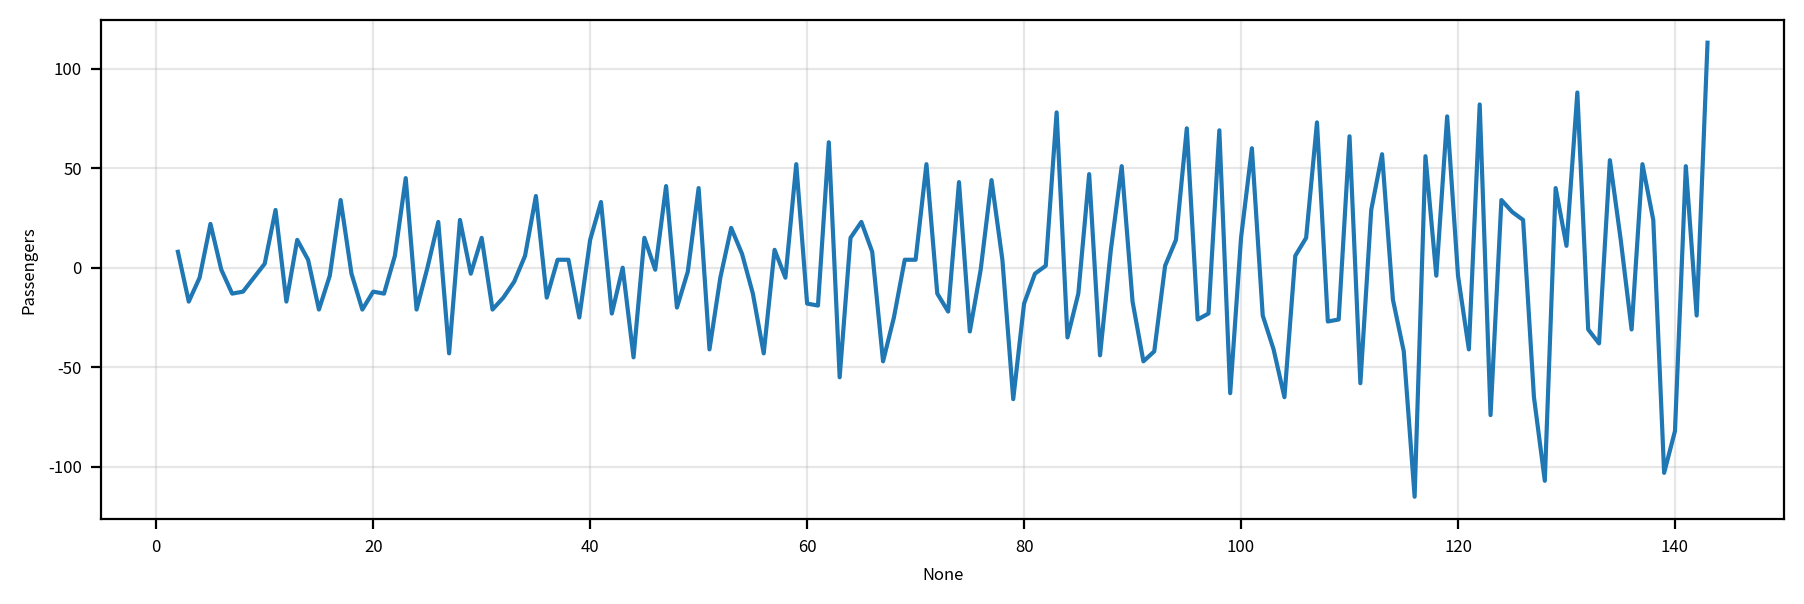

In [8]:
diff_df = origin.copy()
yname = 'Passengers'

diff_count = 0        # 몇 번까지 차분을 수행했는지 count
result = []           # 결과를 저장할 리스트

while True:
    ar = adfuller(diff_df[yname])

    ar_dict = {
        '차수': diff_count,
        'ADF Statistic': ar[0],
        'p-value': ar[1],
        'result': True if ar[1] <= 0.05 else False
    }

    # 리스트에 정상성 검사 결과 저장
    result.append(ar_dict)

    # 정상성 충족 시 반복 종료
    if ar_dict['result']:
        break

    # 정상성이 충족되지 않았다면 차분 수행 후 다시 실행
    diff_count += 1
    diff_df = diff_df.diff().dropna()

# 차분 결과표
display(DataFrame(result))

# 차분 결과 생성된 데이터프레임
display(diff_df.head())

# 차분 결과 시각화
width_px = 1800
height_px = 600
rows = 1
cols = 1

figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(
    rows,
    cols,
    figsize=figsize,
    dpi=my_dpi
)

sb.lineplot(
    data=diff_df,
    x=diff_df.index,
    y=yname,
    ax=ax
)

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()


📘02.ACF(자기상관함수, AutoCorrelation Function) 검정

📝1.ACF 직접 계산하기

In [11]:
# 수치값 계산
acf_vals = acf(diff_df['Passengers'])

threshold = 2/np.sqrt(len(diff_df['Passengers']))

significant_lags = np.where(np.abs(acf_vals) > threshold)[0]

acf_vals, threshold, significant_lags

(array([ 1.        , -0.19100587, -0.19598169, -0.0485473 , -0.20664662,
         0.11939696,  0.02575129,  0.14558204, -0.22613908,  0.01407533,
        -0.2082756 , -0.12089977,  0.78224898, -0.09592873, -0.19547382,
        -0.07034343, -0.14794844,  0.11319557,  0.01921939,  0.13695131,
        -0.24015233,  0.02613065]),
 np.float64(0.16783627165933782),
 array([ 0,  1,  2,  4,  8, 10, 12, 14, 20]))

결과표 만들기<br>
significant ---> 이 lag가 의미 있는가<br>
prev_significant + cut_candidate ---> 어디서 영향이 끊기는가<br>
lag와 cut_candidate를 함꼐 보면 q또는 p 후보를 판단할  수 있음

ACF, PACF는 모두 q또는 p값을 찾는 과정.<br>
q 또는 p값은 통계적 시계열 분석인 ARIMA의 파라미터가 된다

In [25]:
# 1) ACF 계산
acf_vals = acf(diff_df['Passengers'])
threshold = 2 / np.sqrt(len(diff_df['Passengers']))

# 2) 결과표 생성
df_acf = DataFrame({
    "lag": np.arange(len(acf_vals)),
    "acf": acf_vals,
})

# 3) 유의성 판단
df_acf["abs_acf"] = df_acf["acf"].abs()
df_acf["significant"] = df_acf["abs_acf"] > threshold

# 4) 보기 좋게 정리
df_acf["acf"] = df_acf["acf"].round(3)
df_acf["abs_acf"] = df_acf["abs_acf"].round(3)
df_acf["threshold"] = round(threshold, 3)

# 5) lag=0 제외 (관행)
df_acf_result = (
    df_acf
    .query("lag > 0")
    .reset_index(drop=True)
)

# 6) 연속 유의 구간 판단
df_acf_result["prev_significant"] = df_acf_result["significant"].shift(1)

df_acf_result["cut_candidate"] = (
    (df_acf_result["prev_significant"] == True) &
    (df_acf_result["significant"] == False)
)

# 결과 확인
df_acf_result[["lag", "acf", "significant", "cut_candidate"]]
df_acf_result



,lag,acf,abs_acf,significant,threshold,prev_significant,cut_candidate
0,1,-0.191,0.191,True,0.168,NaN,False
1,2,-0.196,0.196,True,0.168,True,False
2,3,-0.049,0.049,False,0.168,True,True
3,4,-0.207,0.207,True,0.168,False,False
4,5,0.119,0.119,False,0.168,True,True
5,6,0.026,0.026,False,0.168,False,False
6,7,0.146,0.146,False,0.168,False,False
7,8,-0.226,0.226,True,0.168,False,False
8,9,0.014,0.014,False,0.168,True,True
9,10,-0.208,0.208,True,0.168,False,False


📝3)결과표 판정

📝2.ACF Plot

In [27]:
q_candidate = (
    df_acf_result.loc[df_acf_result["cut_candidate"], "lag"]
    .min()-1
)

q_candidate

np.int64(2)

📝ACF Plot 시각화

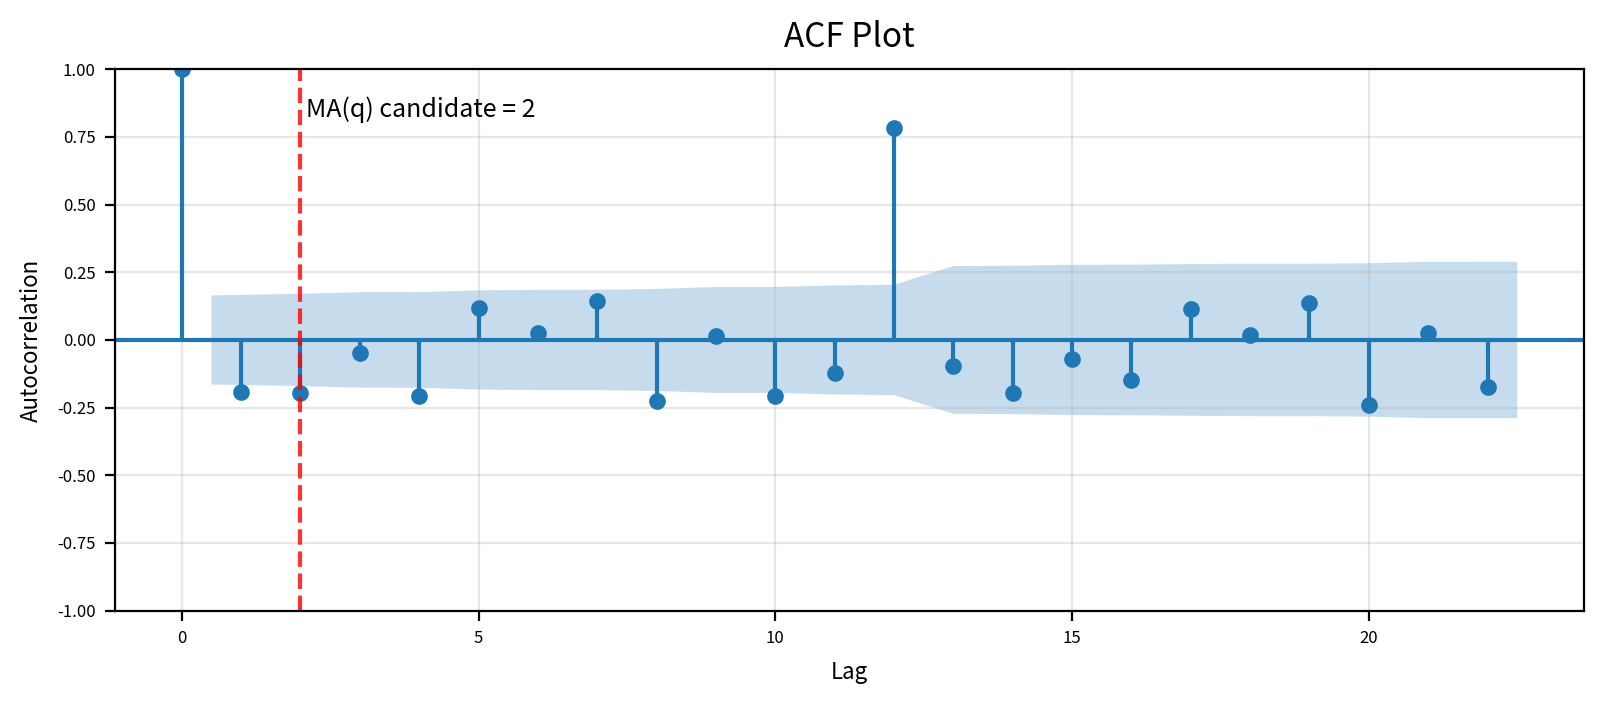

In [28]:
# 1) 그래프 초기화
width_px = 1600          # 그래프 가로 크기
height_px = 700          # 그래프 세로 크기
rows = 1                 # 그래프 행 수
cols = 1                 # 그래프 열 수

figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(
    rows,
    cols,
    figsize=figsize,
    dpi=my_dpi
)

# 2-1) ACF Plot 그리기 → ax 파라미터 필수
plot_acf(
    diff_df['Passengers'],
    ax=ax
)

# 2-2) MA(q) 후보 시각화
ax.axvline(
    x=q_candidate,
    linestyle='--',
    linewidth=1.5,
    alpha=0.8,
    color='red'
)

ax.text(
    q_candidate + 0.1,
    ax.get_ylim()[1] * 0.9,
    f"MA(q) candidate = {q_candidate}",
    fontsize=9,
    verticalalignment='top'
)

# 3) 그래프 꾸미기
ax.set_title("ACF Plot", fontsize=12, pad=8)
ax.set_xlabel("Lag", fontsize=8, labelpad=5)
ax.set_ylabel("Autocorrelation", fontsize=8, labelpad=5)
ax.grid(True, alpha=0.3)

# 4) 출력
plt.tight_layout()
plt.show()
plt.close()


📘03.PACf(부분자기상관함수, Partial AutoCorrelation Function)

📝1.PACF 직접 계산하기

In [46]:
# 1)PACF 계산
pacf_vals = pacf(diff_df['Passengers'])
threshold = 2/np.sqrt(len(diff_df['Passengers']))

# 2)결과표 생성
df_pacf = DataFrame({
    "lag":np.arange(len(pacf_vals)),
    "pacf":pacf_vals,
})

# 3)유의성 판단
df_pacf["abs_pacf"] = df_pacf["pacf"].abs()
df_pacf["significant"]= df_pacf["abs_pacf"] > threshold

# 4)보기 좋게 정리
df_pacf["pacf"] = df_pacf["pacf"].round(3)
df_pacf["abs_pacf"] = df_pacf["abs_pacf"].round(3)
df_pacf["threshold"] = round(threshold, 3)

# 5)lag=0 제외
df_pacf_result = df_pacf.query("lag > 0"). reset_index(drop=True)

# 5)연속 유의구간 계산
df_pacf_result["prev_significant"] = df_pacf_result["significant"].shift(1)

df_pacf_result["cut_candidate"] = (
    (df_pacf_result["prev_significant"] == True)&
    (df_pacf_result["significant"] == False)
)

df_pacf_result[["lag", "pacf", "significant", "cut_candidate"]]

df_pacf_result

,lag,pacf,abs_pacf,significant,threshold,prev_significant,cut_candidate
0,1,-0.192,0.192,True,0.168,NaN,False
1,2,-0.245,0.245,True,0.168,True,False
2,3,-0.159,0.159,False,0.168,True,True
3,4,-0.355,0.355,True,0.168,False,False
4,5,-0.112,0.112,False,0.168,True,True
5,6,-0.169,0.169,True,0.168,False,False
6,7,0.078,0.078,False,0.168,True,True
7,8,-0.329,0.329,True,0.168,False,False
8,9,-0.075,0.075,False,0.168,True,True
9,10,-0.596,0.596,True,0.168,False,False


✏️결과표 판정

📝2.PACF Plot

In [40]:
# ✏️P후보(연속 유의 구간의 마지막 lag)
p_candidate = (
    df_pacf_result
    .loc[df_pacf_result["cut_candidate"], "lag"]
    .min() - 1


)

p_candidate

np.int64(2)

✏️PACF Plot 시각화

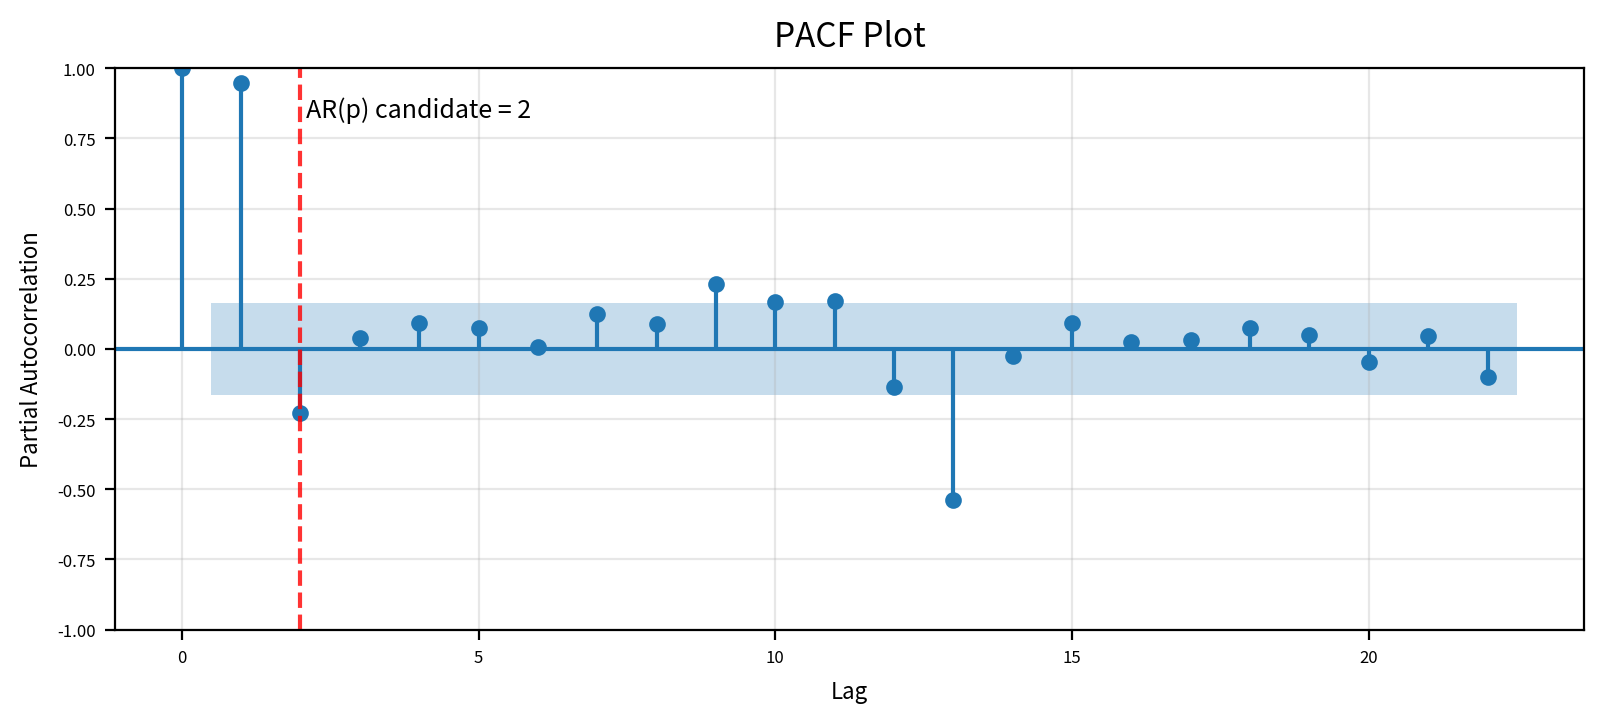

In [42]:
# 1) 그래프 초기화
width_px = 1600
height_px = 720
rows = 1
cols = 1

figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(
    rows,
    cols,
    figsize=figsize,
    dpi=my_dpi
)

# 2-1) PACF Plot 그리기
plot_pacf(
    origin['Passengers'],
    ax=ax
)

# 2-2) AR(p) 후보 시각화
ax.axvline(
    x=p_candidate,
    linestyle='--',
    linewidth=1.5,
    alpha=0.8,
    color='red'
)

ax.text(
    p_candidate + 0.1,
    ax.get_ylim()[1] * 0.9,
    f"AR(p) candidate = {p_candidate}",
    fontsize=9,
    verticalalignment='top'
)

# 3) 그래프 꾸미기
ax.set_title("PACF Plot", fontsize=12, pad=8)
ax.set_xlabel("Lag", fontsize=8, labelpad=5)
ax.set_ylabel("Partial Autocorrelation", fontsize=8, labelpad=5)
ax.grid(True, alpha=0.3)

# 4) 출력
plt.tight_layout()
plt.show()
plt.close()


📘04.결과 판정<br>
📝1.ACF / PACF를 이용한 모형 판정 기준<br>
📝2.왜 ACF 와 PACF를 함께 보는가<br>
📝3.ACF, PACF 결과 종합

for i in range(0, p +1):
    for j in range(0, q+1):
        ARIMA(i, 2, j)

for d in [1,2]:
    for i in range(0, p +1):
        ARIMA(i,d,j)